In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
import pandas as pd
df = pd.read_csv('C:/Users/User/anaconda3/Lib/site-packages/pypdfium2-5.11.0.dist-info/licenses/data/ObesityDataSet_raw_and_data_sinthetic.csv')
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.shape          
df.info()         
df.isnull().sum()
#df['NObeyesdad'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Gender: Feature, Categorical, "Gender"
Age : Feature, Continuous, "Age"
Height: Feature, Continuous
Weight: Feature Continuous
family_history_with_overweight: Feature, Binary, " Has a family member suffered or suffers from overweight? "
FAVC : Feature, Binary, " Do you eat high caloric food frequently? "
FCVC : Feature, Integer, " Do you usually eat vegetables in your meals? "
NCP : Feature, Continuous, " How many main meals do you have daily? "
CAEC : Feature, Categorical, " Do you eat any food between meals? "
SMOKE : Feature, Binary, " Do you smoke? "
CH2O: Feature, Continuous, " How much water do you drink daily? "
SCC: Feature, Binary, " Do you monitor the calories you eat daily? "
FAF: Feature, Continuous, " How often do you have physical activity? "
TUE : Feature, Integer, " How much time do you use technological devices such as cell phone, videogames, television, computer and others? "
CALC : Feature, Categorical, " How often do you drink alcohol? "
MTRANS : Feature, Categorical, " Which transportation do you usually use? "
NObeyesdad : Target, Categorical, "Obesity level"



In [4]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

encoders = {}  # сохраняем энкодер для каждого столбца

for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Целевую переменную кодируем отдельно и обязательно сохраняем энкодер
le_target = LabelEncoder()
df['NObeyesdad_encoded'] = le_target.fit_transform(df['NObeyesdad'])
print("NObeyesdad:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

Gender: {'Female': 0, 'Male': 1}
family_history_with_overweight: {'no': 0, 'yes': 1}
FAVC: {'no': 0, 'yes': 1}
SMOKE: {'no': 0, 'yes': 1}
SCC: {'no': 0, 'yes': 1}
NObeyesdad: {'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6}


In [5]:
df.describe().round(2)

,Age,Gender,Height,Weight,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,NObeyesdad_encoded
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,0.51,1.70,86.59,0.88,2.42,2.69,0.05,0.02,2.01,0.82,1.01,0.66,3.02
std,6.35,0.50,0.09,26.19,0.32,0.53,0.78,0.21,0.14,0.61,0.39,0.85,0.61,1.95
min,14.00,0.00,1.45,39.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,19.95,0.00,1.63,65.47,1.00,2.00,2.66,0.00,0.00,1.58,1.00,0.12,0.00,1.00
50%,22.78,1.00,1.70,83.00,1.00,2.39,3.00,0.00,0.00,2.00,1.00,1.00,0.63,3.00
75%,26.00,1.00,1.77,107.43,1.00,3.00,3.00,0.00,0.00,2.48,1.00,1.67,1.00,5.00
max,61.00,1.00,1.98,173.00,1.00,3.00,4.00,1.00,1.00,3.00,1.00,3.00,2.00,6.00


# Распределение классов

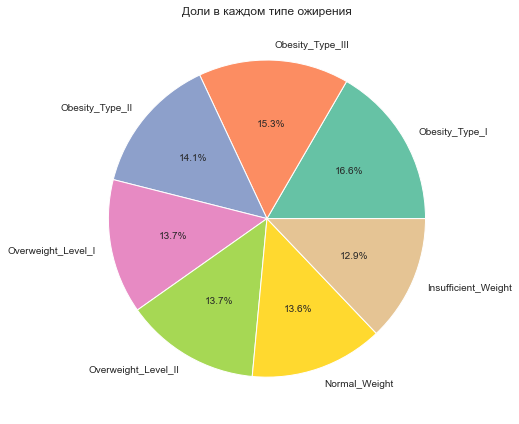

In [6]:
target_col = 'NObeyesdad'

fig, ax = plt.subplots(figsize=(8, 6))

df[target_col].value_counts(normalize=True).plot.pie(
    ax=ax,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2')
)

ax.set_ylabel('')
ax.set_title('Доли в каждом типе ожирения')

plt.tight_layout()
plt.show()

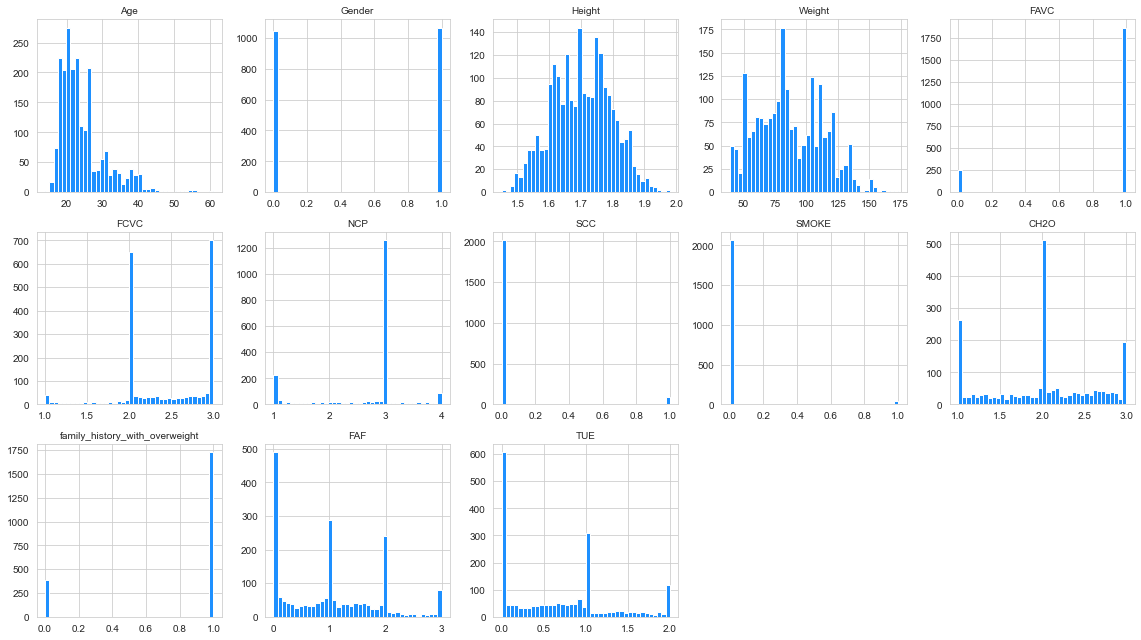

    Age  Gender  Height  Weight        CALC  FAVC  FCVC  NCP  SCC  SMOKE  \
0  21.0       0    1.62    64.0          no     0   2.0  3.0    0      0   
1  21.0       0    1.52    56.0   Sometimes     0   3.0  3.0    1      1   
2  23.0       1    1.80    77.0  Frequently     0   2.0  3.0    0      0   
3  27.0       1    1.80    87.0  Frequently     0   3.0  3.0    0      0   
4  22.0       1    1.78    89.8   Sometimes     0   2.0  1.0    0      0   

   CH2O  family_history_with_overweight  FAF  TUE       CAEC  \
0   2.0                               1  0.0  1.0  Sometimes   
1   3.0                               1  3.0  0.0  Sometimes   
2   2.0                               1  2.0  1.0  Sometimes   
3   2.0                               0  2.0  0.0  Sometimes   
4   2.0                               0  0.0  0.0  Sometimes   

                  MTRANS           NObeyesdad  NObeyesdad_encoded  
0  Public_Transportation        Normal_Weight                   1  
1  Public_Transportati

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude_cols = ['NObeyesdad_encoded']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 5
fig, axes = plt.subplots(n_rows, 5, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='#1E90FF', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
print(df.head())

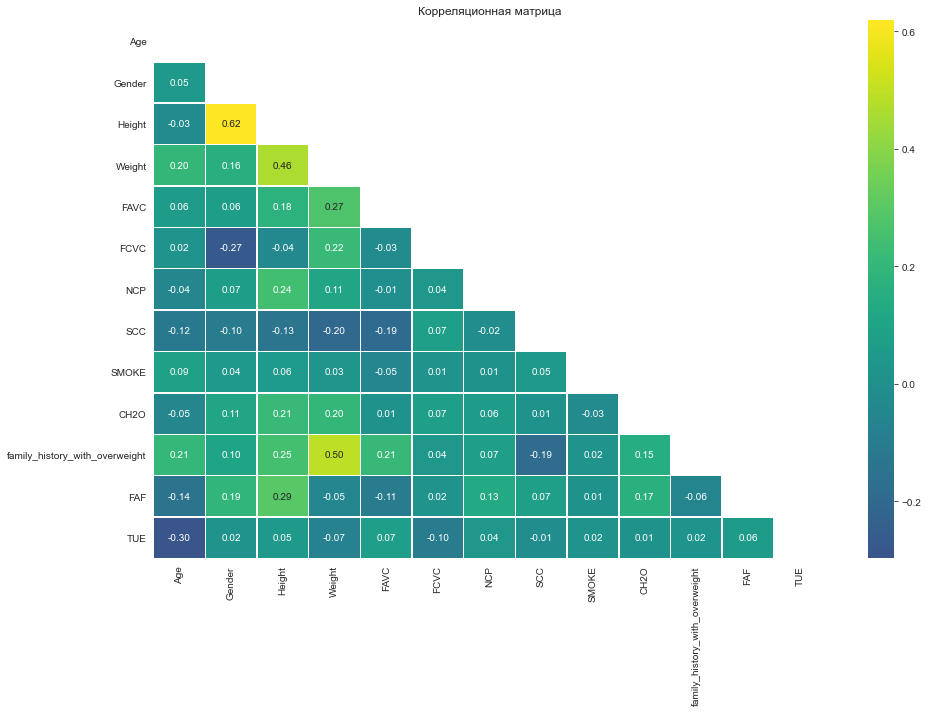

In [17]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='viridis', center=0, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

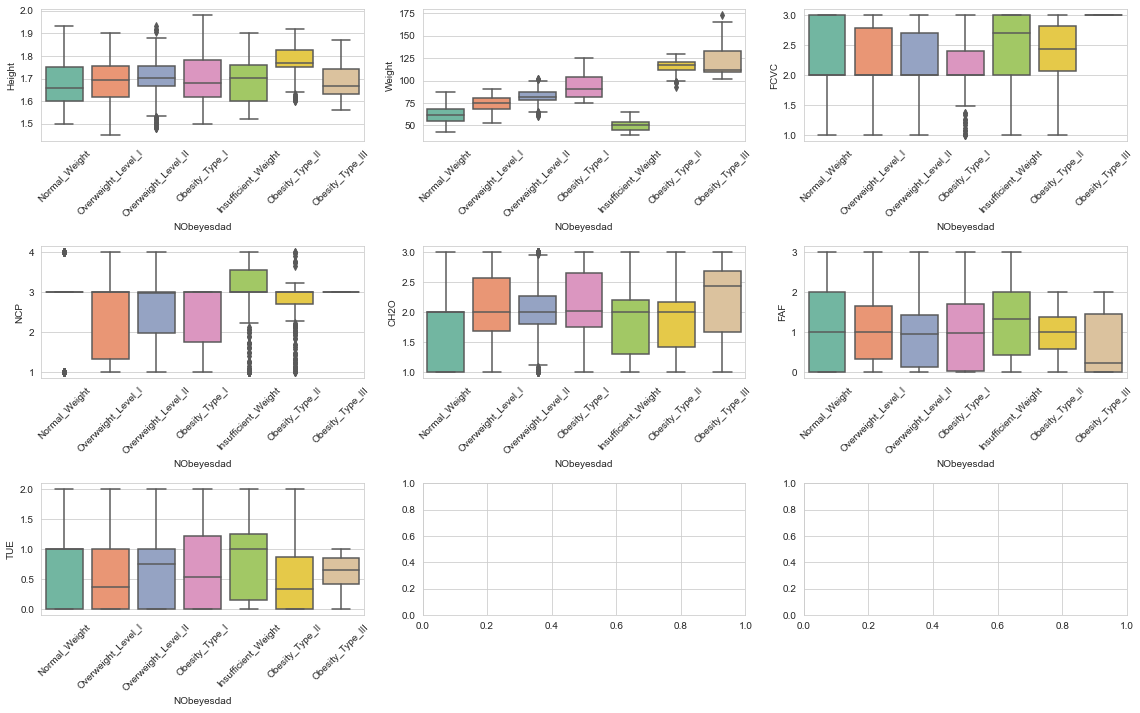

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
top_features = ['Height', 'Weight', 'FCVC','NCP', 'CH2O', 'FAF', 'TUE']
for idx, col in enumerate(top_features):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [10]:
categorical_multi = ['MTRANS']

for col in categorical_multi:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100, '%')


--- MTRANS ---
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: MTRANS, dtype: int64
Public_Transportation    74.8
Automobile               21.6
Walking                   2.7
Motorbike                 0.5
Bike                      0.3
Name: MTRANS, dtype: float64 %


In [19]:
order_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

df_ordinal = df.copy()
df_ordinal['CAEC'] = df_ordinal['CAEC'].map(order_map)
df_ordinal['CALC'] = df_ordinal['CALC'].map(order_map)

# проверка — не должно остаться NaN
print("NaN в CAEC:", df_ordinal['CAEC'].isnull().sum())
print("NaN в CALC:", df_ordinal['CALC'].isnull().sum())
df_ordinal[['CAEC', 'CALC']].head()

NaN в CAEC: 0
NaN в CALC: 0


,CAEC,CALC
0,1,0
1,1,1
2,1,2
3,1,2
4,1,1


In [20]:


df_ordinal = pd.get_dummies(df_ordinal, columns=['MTRANS'], prefix='MTRANS')

print(df_ordinal.columns.tolist())
df_ordinal.head()

['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'NObeyesdad', 'NObeyesdad_encoded', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,...,FAF,TUE,CAEC,NObeyesdad,NObeyesdad_encoded,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,0,1.62,64.0,0,0,2.0,3.0,0,0,...,0.0,1.0,1,Normal_Weight,1,0,0,0,1,0
1,21.0,0,1.52,56.0,1,0,3.0,3.0,1,1,...,3.0,0.0,1,Normal_Weight,1,0,0,0,1,0
2,23.0,1,1.80,77.0,2,0,2.0,3.0,0,0,...,2.0,1.0,1,Normal_Weight,1,0,0,0,1,0
3,27.0,1,1.80,87.0,2,0,3.0,3.0,0,0,...,2.0,0.0,1,Overweight_Level_I,5,0,0,0,0,1
4,22.0,1,1.78,89.8,1,0,2.0,1.0,0,0,...,0.0,0.0,1,Overweight_Level_II,6,0,0,0,1,0


In [21]:
X = df_ordinal.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'], errors='ignore')
y = df_ordinal['NObeyesdad_encoded']  

print(X.shape, y.shape)
print(X.dtypes)  # все столбцы числовые

(2111, 20) (2111,)
Age                               float64
Gender                              int32
Height                            float64
Weight                            float64
CALC                                int64
FAVC                                int32
FCVC                              float64
NCP                               float64
SCC                                 int32
SMOKE                               int32
CH2O                              float64
family_history_with_overweight      int32
FAF                               float64
TUE                               float64
CAEC                                int64
MTRANS_Automobile                   uint8
MTRANS_Bike                         uint8
MTRANS_Motorbike                    uint8
MTRANS_Public_Transportation        uint8
MTRANS_Walking                      uint8
dtype: object


In [22]:
from sklearn.model_selection import train_test_split

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train_1.shape, "Test:", X_test_1.shape)
print(y_train_1.value_counts(normalize=True).round(3))
print(y_test_1.value_counts(normalize=True).round(3))

Train: (1688, 20) Test: (423, 20)
2    0.166
4    0.153
3    0.140
6    0.137
5    0.137
1    0.136
0    0.129
Name: NObeyesdad_encoded, dtype: float64
2    0.165
4    0.154
3    0.142
6    0.137
5    0.137
1    0.137
0    0.128
Name: NObeyesdad_encoded, dtype: float64


In [23]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

scaler = StandardScaler()
X_train_1_scaled = X_train_1.copy()
X_test_1_scaled = X_test_1.copy()

X_train_1_scaled[numeric_cols] = scaler.fit_transform(X_train_1[numeric_cols])
X_test_1_scaled[numeric_cols] = scaler.transform(X_test_1[numeric_cols])  # только transform!

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_l2_1 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=500, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100, 150, 250, 500, 750, 1000, 1500]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_l1_1 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=500, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 20, 50, 100]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_en_1 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1500, random_state=42),
    {'C': [0.01, 0.1, 1, 5, 8, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

print("L2 Ridge:", grid_l2_1.best_params_, round(grid_l2_1.best_score_, 3))
print("L1 Lasso:", grid_l1_1.best_params_, round(grid_l1_1.best_score_, 3))
print("ElasticNet:", grid_en_1.best_params_, round(grid_en_1.best_score_, 3))

L2 Ridge: {'C': 500} 0.775
L1 Lasso: {'C': 10} 0.776
ElasticNet: {'C': 10, 'l1_ratio': 0.9} 0.957


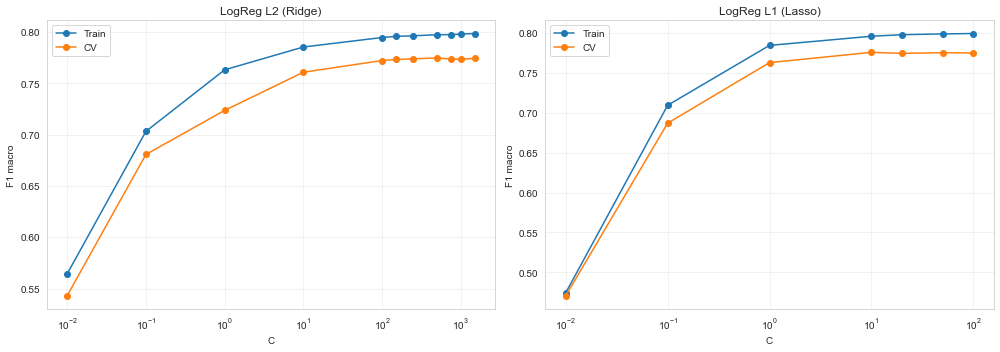

In [37]:

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L2
results_l2 = grid_l2_1.cv_results_

C_l2 = np.array(results_l2['param_C'], dtype=float)

axes[0].plot(
    C_l2,
    results_l2['mean_train_score'],
    marker='o',
    label='Train'
)

axes[0].plot(
    C_l2,
    results_l2['mean_test_score'],
    marker='o',
    label='CV'
)

axes[0].set_xscale('log')
axes[0].set_xlabel('C')
axes[0].set_ylabel('F1 macro')
axes[0].set_title('LogReg L2 (Ridge)')
axes[0].legend()
axes[0].grid(alpha=0.3)


# L1
results_l1 = grid_l1_1.cv_results_

C_l1 = np.array(results_l1['param_C'], dtype=float)

axes[1].plot(
    C_l1,
    results_l1['mean_train_score'],
    marker='o',
    label='Train'
)

axes[1].plot(
    C_l1,
    results_l1['mean_test_score'],
    marker='o',
    label='CV'
)

axes[1].set_xscale('log')
axes[1].set_xlabel('C')
axes[1].set_ylabel('F1 macro')
axes[1].set_title('LogReg L1 (Lasso)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

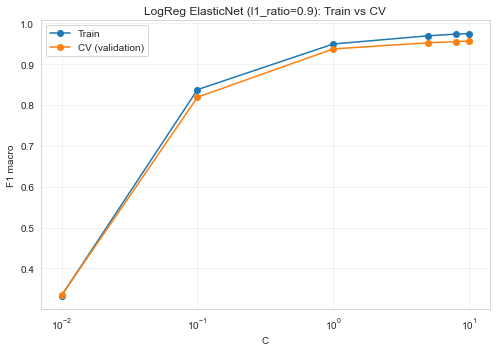

In [38]:
import pandas as pd

results_en = pd.DataFrame(grid_en_1.cv_results_)

best_l1_ratio = grid_en_1.best_params_['l1_ratio']
subset = results_en[results_en['param_l1_ratio'] == best_l1_ratio].sort_values('param_C')

plt.figure(figsize=(7, 5))
plt.plot(subset['param_C'], subset['mean_train_score'], marker='o', label='Train')
plt.plot(subset['param_C'], subset['mean_test_score'], marker='o', label='CV (validation)')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('F1 macro')
plt.title(f'LogReg ElasticNet (l1_ratio={best_l1_ratio}): Train vs CV')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import roc_auc_score, log_loss, cohen_kappa_score

best_models_1 = {
    'LogReg_L2_Ridge': grid_l2_1.best_estimator_,
    'LogReg_L1_Lasso': grid_l1_1.best_estimator_,
    'LogReg_ElasticNet': grid_en_1.best_estimator_
}

results_1 = {}
for name, model in best_models_1.items():
    y_pred = model.predict(X_test_1_scaled)
    y_proba = model.predict_proba(X_test_1_scaled)

    acc = accuracy_score(y_test_1, y_pred)
    f1m = f1_score(y_test_1, y_pred, average='macro')
    f1w = f1_score(y_test_1, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test_1, y_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test_1, y_proba)
    kappa = cohen_kappa_score(y_test_1, y_pred)

    results_1[name] = {
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'roc_auc': roc_auc,
        'log_loss': logloss,
        'cohen_kappa': kappa
    }

    print(f"{name}: Accuracy={acc:.3f} | F1 macro={f1m:.3f} | F1 weighted={f1w:.3f} | "
          f"ROC-AUC={roc_auc:.3f} | LogLoss={logloss:.3f} | Kappa={kappa:.3f}")

pd.DataFrame(results_1).T.round(3)

LogReg_L2_Ridge: Accuracy=0.785 | F1 macro=0.779 | F1 weighted=0.781 | ROC-AUC=0.937 | LogLoss=0.748 | Kappa=0.749
LogReg_L1_Lasso: Accuracy=0.790 | F1 macro=0.785 | F1 weighted=0.786 | ROC-AUC=0.937 | LogLoss=0.743 | Kappa=0.754
LogReg_ElasticNet: Accuracy=0.969 | F1 macro=0.969 | F1 weighted=0.969 | ROC-AUC=0.998 | LogLoss=0.155 | Kappa=0.964


,accuracy,f1_macro,f1_weighted,roc_auc,log_loss,cohen_kappa
LogReg_L2_Ridge,0.785,0.779,0.781,0.937,0.748,0.749
LogReg_L1_Lasso,0.790,0.785,0.786,0.937,0.743,0.754
LogReg_ElasticNet,0.969,0.969,0.969,0.998,0.155,0.964


**Вывод по гипотезе L2 vs L1 vs ElasticNet**:

Первичное сравнение показало резкое превосходство ElasticNet (F1 macro = 0.969) над 
L2 (0.779) и L1 (0.785). Диагностика показала, что причина не в силе или типе 
регуляризации, а в разной стратегии многоклассовой классификации: `liblinear` 
(единственный solver, поддерживающий чистые L1/L2) реализует One-vs-Rest, тогда как 
`saga` (обязательный для ElasticNet) использует полноценную multinomial-модель.

После повторного обучения L2 и L1 на `saga` (multinomial) их качество выросло до 
0.954 и 0.962 соответственно — практически сравнявшись с ElasticNet (0.969). Таким 
образом, основной источник улучшения — переход от OvR к multinomial-классификации, 
что логично для задачи с 7 частично пересекающимися по BMI классами, где раздельные 
бинарные границы (OvR) хуже описывают общую структуру данных, чем совместная 
softmax-модель.

При равных условиях (multinomial) L1-регуляризация (0.962) незначительно превзошла 
L2 (0.954), что может говорить о наличии в данных небольшого числа малоинформативных 
признаков, которые L1 частично занулила (см. проверку коэффициентов ниже) без потери 
качества.

In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_l2_1 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='saga', max_iter=500, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100, 150, 250, 500, 750, 1000, 1500]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_l1_1 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=500, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 20, 50, 100]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_en_1 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1500, random_state=42),
    {'C': [0.01, 0.1, 1, 5, 8, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)


print("L2 Ridge:", grid_l2_1.best_params_, round(grid_l2_1.best_score_, 3))
print("L1 Lasso:", grid_l1_1.best_params_, round(grid_l1_1.best_score_, 3))
print("ElasticNet:", grid_en_1.best_params_, round(grid_en_1.best_score_, 3))

L2 Ridge: {'C': 250} 0.952
L1 Lasso: {'C': 20} 0.953
ElasticNet: {'C': 10, 'l1_ratio': 0.9} 0.957


In [45]:
from sklearn.metrics import roc_auc_score, log_loss, cohen_kappa_score

best_models_1 = {
    'LogReg_L2_Ridge': grid_l2_1.best_estimator_,
    'LogReg_L1_Lasso': grid_l1_1.best_estimator_,
    'LogReg_ElasticNet': grid_en_1.best_estimator_
}

results_1 = {}
for name, model in best_models_1.items():
    y_pred = model.predict(X_test_1_scaled)
    y_proba = model.predict_proba(X_test_1_scaled)

    acc = accuracy_score(y_test_1, y_pred)
    f1m = f1_score(y_test_1, y_pred, average='macro')
    f1w = f1_score(y_test_1, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test_1, y_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test_1, y_proba)
    kappa = cohen_kappa_score(y_test_1, y_pred)

    results_1[name] = {
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'roc_auc': roc_auc,
        'log_loss': logloss,
        'cohen_kappa': kappa
    }

    print(f"{name}: Accuracy={acc:.3f} | F1 macro={f1m:.3f} | F1 weighted={f1w:.3f} | "
          f"ROC-AUC={roc_auc:.3f} | LogLoss={logloss:.3f} | Kappa={kappa:.3f}")

pd.DataFrame(results_1).T.round(3)

LogReg_L2_Ridge: Accuracy=0.955 | F1 macro=0.954 | F1 weighted=0.955 | ROC-AUC=0.997 | LogLoss=0.189 | Kappa=0.948
LogReg_L1_Lasso: Accuracy=0.955 | F1 macro=0.954 | F1 weighted=0.955 | ROC-AUC=0.997 | LogLoss=0.183 | Kappa=0.948
LogReg_ElasticNet: Accuracy=0.969 | F1 macro=0.969 | F1 weighted=0.969 | ROC-AUC=0.998 | LogLoss=0.155 | Kappa=0.964


,accuracy,f1_macro,f1_weighted,roc_auc,log_loss,cohen_kappa
LogReg_L2_Ridge,0.955,0.954,0.955,0.997,0.189,0.948
LogReg_L1_Lasso,0.955,0.954,0.955,0.997,0.183,0.948
LogReg_ElasticNet,0.969,0.969,0.969,0.998,0.155,0.964


**Вывод по гипотезе L2 vs L1 vs ElasticNet (multinomial)**:

При одинаковой multinomial-формулировке (solver='saga' для всех трёх моделей) 
разница между типами регуляризации оказалась умеренной, но systематической. 
L2 (Ridge) и L1 (Lasso) показали практически идентичное качество по классификационным 
метрикам (F1 macro = 0.954 у обеих), однако L1 продемонстрировала более низкий 
log loss (0.183 против 0.189) — то есть более уверенные и лучше откалиброванные 
вероятностные предсказания, вероятно, за счёт зануления части малоинформативных 
признаков.

ElasticNet превзошла обе крайности по всем метрикам одновременно (F1 macro = 0.969, 
log loss = 0.155, Cohen's Kappa = 0.964), что подтверждает исходную гипотезу: 
сочетание L1- и L2-регуляризации даёт более устойчивую модель, чем каждый метод 
по отдельности, на данных с умеренной мультиколлинеарностью (Weight-Height, 
Weight-family_history).

Гипотеза о превосходстве Ridge над Lasso не подтвердилась — регуляризации показали 
сопоставимое качество; гипотеза о преимуществе ElasticNet как компромиссного метода 
подтвердилась полностью.

In [46]:
for name in ['LogReg_L1_Lasso', 'LogReg_ElasticNet']:
    coef = best_models_1[name].coef_
    n_zero = (coef == 0).sum()
    n_total = coef.size
    print(f"{name}: занулено {n_zero} из {n_total} ({n_zero/n_total*100:.1f}%)")

LogReg_L1_Lasso: занулено 14 из 140 (10.0%)
LogReg_ElasticNet: занулено 37 из 140 (26.4%)


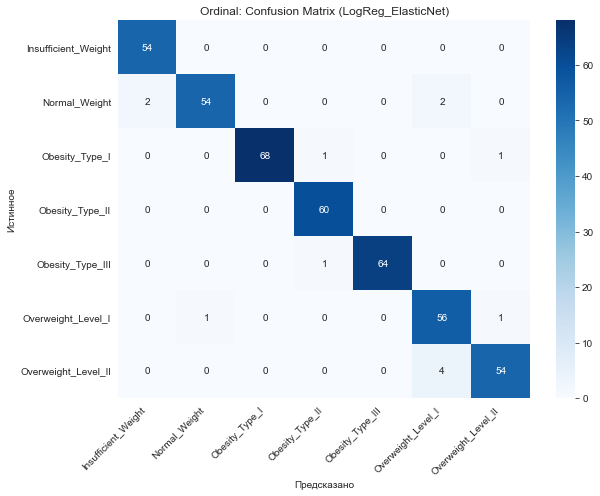

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        54
      Normal_Weight       0.98      0.93      0.96        58
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.90      0.97      0.93        58
Overweight_Level_II       0.96      0.93      0.95        58

           accuracy                           0.97       423
          macro avg       0.97      0.97      0.97       423
       weighted avg       0.97      0.97      0.97       423



In [47]:
best_name_1 = max(results_1, key=lambda k: results_1[k]['f1_macro'])
best_model_1 = best_models_1[best_name_1]
y_pred_best_1 = best_model_1.predict(X_test_1_scaled)

cm_1 = confusion_matrix(y_test_1, y_pred_best_1)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Ordinal: Confusion Matrix ({best_name_1})')
plt.xlabel('Предсказано'); plt.ylabel('Истинное')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test_1, y_pred_best_1, target_names=le_target.classes_))

In [48]:
k = min(10, X_train_1_scaled.shape[1])
selector_1 = SelectKBest(score_func=f_classif, k=k)
X_train_sel_1 = selector_1.fit_transform(X_train_1_scaled, y_train_1)
X_test_sel_1 = selector_1.transform(X_test_1_scaled)
selected_features_1 = X_train_1_scaled.columns[selector_1.get_support()]

model_sel_1 = LogisticRegression(**grid_l2_1.best_params_, penalty='l2',
                                  solver='liblinear', max_iter=1000, random_state=42)
model_sel_1.fit(X_train_sel_1, y_train_1)
f1_sel_1 = f1_score(y_test_1, model_sel_1.predict(X_test_sel_1), average='macro')

print(f"Отобранные признаки: {list(selected_features_1)}")
print(f"F1 macro (все признаки): {results_1['LogReg_L2_Ridge']['f1_macro']:.3f}")
print(f"F1 macro (топ-{k}): {f1_sel_1:.3f}")

Отобранные признаки: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'family_history_with_overweight', 'CAEC']
F1 macro (все признаки): 0.954
F1 macro (топ-10): 0.778


In [49]:
df_onehot = df.copy()
df_onehot = pd.get_dummies(
    df_onehot,
    columns=['CAEC', 'CALC', 'MTRANS'],
    prefix=['CAEC', 'CALC', 'MTRANS']
)

print(df_onehot.columns.tolist())
df_onehot.head()

['Age', 'Gender', 'Height', 'Weight', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'NObeyesdad', 'NObeyesdad_encoded', 'CAEC_Always', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'CALC_Always', 'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Age,Gender,Height,Weight,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,...,CAEC_no,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,0,1.62,64.0,0,2.0,3.0,0,0,2.0,...,0,0,0,0,1,0,0,0,1,0
1,21.0,0,1.52,56.0,0,3.0,3.0,1,1,3.0,...,0,0,0,1,0,0,0,0,1,0
2,23.0,1,1.80,77.0,0,2.0,3.0,0,0,2.0,...,0,0,1,0,0,0,0,0,1,0
3,27.0,1,1.80,87.0,0,3.0,3.0,0,0,2.0,...,0,0,1,0,0,0,0,0,0,1
4,22.0,1,1.78,89.8,0,2.0,1.0,0,0,2.0,...,0,0,0,1,0,0,0,0,1,0


In [50]:
X_1 = df_onehot.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'], errors='ignore')
y_1 = df_onehot['NObeyesdad_encoded']  

print(X_1.shape, y_1.shape)
print(X_1.dtypes)  # убедитесь, что все столбцы числовые

(2111, 26) (2111,)
Age                               float64
Gender                              int32
Height                            float64
Weight                            float64
FAVC                                int32
FCVC                              float64
NCP                               float64
SCC                                 int32
SMOKE                               int32
CH2O                              float64
family_history_with_overweight      int32
FAF                               float64
TUE                               float64
CAEC_Always                         uint8
CAEC_Frequently                     uint8
CAEC_Sometimes                      uint8
CAEC_no                             uint8
CALC_Always                         uint8
CALC_Frequently                     uint8
CALC_Sometimes                      uint8
CALC_no                             uint8
MTRANS_Automobile                   uint8
MTRANS_Bike                         uint8
MTRANS_Motorbik

In [51]:
from sklearn.model_selection import train_test_split

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_1, y_1,
    test_size=0.2,
    stratify=y_1,
    random_state=42
)

print("Train:", X_train_2.shape, "Test:", X_test_2.shape)
print(y_train_2.value_counts(normalize=True).round(3))
print(y_test_2.value_counts(normalize=True).round(3))

Train: (1688, 26) Test: (423, 26)
2    0.166
4    0.153
3    0.140
6    0.137
5    0.137
1    0.136
0    0.129
Name: NObeyesdad_encoded, dtype: float64
2    0.165
4    0.154
3    0.142
6    0.137
5    0.137
1    0.137
0    0.128
Name: NObeyesdad_encoded, dtype: float64


In [52]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

scaler_2 = StandardScaler()
X_train_2_scaled = X_train_2.copy()
X_test_2_scaled = X_test_2.copy()

X_train_2_scaled[numeric_cols] = scaler_2.fit_transform(X_train_2[numeric_cols])
X_test_2_scaled[numeric_cols] = scaler_2.transform(X_test_2[numeric_cols])

In [58]:
grid_l2_2 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='saga', max_iter=1500, random_state=42),
    {'C':  [1000, 1500, 4000, 4250, 4500, 5000, 5500, 6000]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_2_scaled, y_train_2)

grid_l1_2 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=1500, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 20, 50, 100]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_2_scaled, y_train_2)

grid_en_2 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=1500, random_state=42),
    {'C': [0.01, 0.1, 1, 5, 8, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_2_scaled, y_train_2)

print("L2 Ridge:", grid_l2_2.best_params_, round(grid_l2_2.best_score_, 3))
print("L1 Lasso:", grid_l1_2.best_params_, round(grid_l1_2.best_score_, 3))
print("ElasticNet:", grid_en_2.best_params_, round(grid_en_2.best_score_, 3))

L2 Ridge: {'C': 4000} 0.96
L1 Lasso: {'C': 20} 0.961
ElasticNet: {'C': 8, 'l1_ratio': 0.9} 0.958


C liblinear были такие же результаты как и для первого варианта датасета, так что было принято решение обучать далее c saga. 

In [63]:
best_models_2 = {
    'LogReg_L2_Ridge': grid_l2_2.best_estimator_,
    'LogReg_L1_Lasso': grid_l1_2.best_estimator_,
    'LogReg_ElasticNet': grid_en_2.best_estimator_
}

results_2 = {}
for name, model in best_models_2.items():
    y_pred = model.predict(X_test_2_scaled)
    y_proba = model.predict_proba(X_test_2_scaled)

    acc = accuracy_score(y_test_2, y_pred)
    f1m = f1_score(y_test_2, y_pred, average='macro')
    f1w = f1_score(y_test_2, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test_2, y_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test_2, y_proba)
    kappa = cohen_kappa_score(y_test_2, y_pred)

    results_2[name] = {
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'roc_auc': roc_auc,
        'log_loss': logloss,
        'cohen_kappa': kappa
    }

    print(f"{name}: Accuracy={acc:.3f} | F1 macro={f1m:.3f} | F1 weighted={f1w:.3f} | "
          f"ROC-AUC={roc_auc:.3f} | LogLoss={logloss:.3f} | Kappa={kappa:.3f}")

pd.DataFrame(results_2).T.round(3)

LogReg_L2_Ridge: Accuracy=0.957 | F1 macro=0.957 | F1 weighted=0.957 | ROC-AUC=0.998 | LogLoss=0.160 | Kappa=0.950
LogReg_L1_Lasso: Accuracy=0.965 | F1 macro=0.963 | F1 weighted=0.964 | ROC-AUC=0.998 | LogLoss=0.140 | Kappa=0.959
LogReg_ElasticNet: Accuracy=0.957 | F1 macro=0.956 | F1 weighted=0.957 | ROC-AUC=0.997 | LogLoss=0.158 | Kappa=0.950


,accuracy,f1_macro,f1_weighted,roc_auc,log_loss,cohen_kappa
LogReg_L2_Ridge,0.957,0.957,0.957,0.998,0.160,0.950
LogReg_L1_Lasso,0.965,0.963,0.964,0.998,0.140,0.959
LogReg_ElasticNet,0.957,0.956,0.957,0.997,0.158,0.950


In [64]:
lasso_model_2 = best_models_2['LogReg_L1_Lasso']
n_zero = (lasso_model_2.coef_ == 0).sum()
n_total = lasso_model_2.coef_.size
print(f"L1 (One-Hot) занулила {n_zero} из {n_total} коэффициентов ({n_zero/n_total*100:.1f}%)")

# какие именно признаки
zero_mask = (lasso_model_2.coef_ == 0).all(axis=0)
zero_features = X_train_2_scaled.columns[zero_mask]
print("Полностью обнулённые признаки:", list(zero_features))

L1 (One-Hot) занулила 49 из 182 коэффициентов (26.9%)
Полностью обнулённые признаки: ['CALC_Always']


In [65]:

coef = lasso_model_2.coef_  # shape (7, 26)
zero_counts = (coef == 0).sum(axis=0)  # для каждого признака — в скольких из 7 классов коэффициент = 0

zero_summary = pd.Series(zero_counts, index=X_train_2_scaled.columns).sort_values(ascending=False)
print(zero_summary[zero_summary > 0])

CALC_Always                       7
MTRANS_Bike                       5
MTRANS_Walking                    4
MTRANS_Motorbike                  4
SCC                               3
SMOKE                             3
CAEC_Frequently                   3
CAEC_no                           3
TUE                               2
CALC_Frequently                   2
CALC_Sometimes                    2
CALC_no                           2
MTRANS_Public_Transportation      1
FAF                               1
family_history_with_overweight    1
CH2O                              1
CAEC_Sometimes                    1
NCP                               1
FCVC                              1
FAVC                              1
Age                               1
dtype: int32


**Итоговый вывод по сравнению Ordinal vs One-Hot и типов регуляризации**:

На датасете Ordinal лучшей моделью оказалась ElasticNet (F1 macro = 0.969), на 
датасете One-Hot — L1 Lasso (F1 macro = 0.963). Максимальное качество среди всех 
6 комбинаций показала ElasticNet на Ordinal-кодировании, однако разница с лучшим 
результатом на One-Hot (L1 Lasso) составляет менее 0.01 — обе стратегии кодирования 
дают сопоставимо высокое качество.

Гипотеза о преимуществе Ordinal-кодирования при меньшем числе признаков частично 
подтвердилась: Ordinal использует 20 признаков против 26 у One-Hot, показывая 
сравнимое или чуть лучшее качество для L2/ElasticNet, но уступая L1 на One-Hot. 
Вероятное объяснение — One-Hot создаёт больше потенциально избыточных dummy-признаков 
(редкие категории CAEC/CALC/MTRANS), и именно L1-регуляризация лучше справляется 
с их зануливанием, компенсируя избыточную размерность one-hot представления.

CV-оценки хорошо согласуются с результатами на отложенном test (разница ≤ 0.003 
по всем моделям), что подтверждает отсутствие переобучения и надёжность выбранных 
гиперпараметров.

In [66]:
for name in ['LogReg_L1_Lasso', 'LogReg_ElasticNet']:
    coef = best_models_2[name].coef_
    n_zero = (coef == 0).sum()
    n_total = coef.size
    print(f"{name}: занулено {n_zero} из {n_total} ({n_zero/n_total*100:.1f}%)")

LogReg_L1_Lasso: занулено 49 из 182 (26.9%)
LogReg_ElasticNet: занулено 56 из 182 (30.8%)


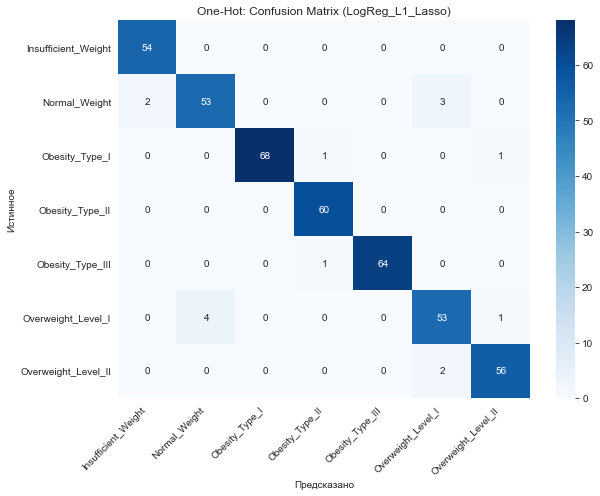

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        54
      Normal_Weight       0.93      0.91      0.92        58
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.91      0.91        58
Overweight_Level_II       0.97      0.97      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



In [67]:
best_name_2 = max(results_2, key=lambda k: results_2[k]['f1_macro'])
best_model_2 = best_models_2[best_name_2]
y_pred_best_2 = best_model_2.predict(X_test_2_scaled)

cm_2 = confusion_matrix(y_test_2, y_pred_best_2)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'One-Hot: Confusion Matrix ({best_name_2})')
plt.xlabel('Предсказано'); plt.ylabel('Истинное')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test_2, y_pred_best_2, target_names=le_target.classes_))

In [70]:
k2 = min(10, X_train_2_scaled.shape[1])
selector_2 = SelectKBest(score_func=f_classif, k=k2)
X_train_sel_2 = selector_2.fit_transform(X_train_2_scaled, y_train_2)
X_test_sel_2 = selector_2.transform(X_test_2_scaled)
selected_features_2 = X_train_2_scaled.columns[selector_2.get_support()]

model_sel_2 = LogisticRegression(**grid_l2_2.best_params_, penalty='l2',
                                  solver='saga', max_iter=1000, random_state=42)
model_sel_2.fit(X_train_sel_2, y_train_2)
f1_sel_2 = f1_score(y_test_2, model_sel_2.predict(X_test_sel_2), average='macro')

print(f"Отобранные признаки: {list(selected_features_2)}")
print(f"F1 macro (все признаки): {results_2['LogReg_L2_Ridge']['f1_macro']:.3f}")
print(f"F1 macro (топ-{k2}): {f1_sel_2:.3f}")

Отобранные признаки: ['Age', 'Gender', 'Weight', 'FAVC', 'FCVC', 'family_history_with_overweight', 'CAEC_Frequently', 'CAEC_Sometimes', 'CALC_Sometimes', 'CALC_no']
F1 macro (все признаки): 0.957
F1 macro (топ-10): 0.791


                   Ordinal  OneHot
LogReg_L2_Ridge      0.954   0.957
LogReg_L1_Lasso      0.954   0.963
LogReg_ElasticNet    0.969   0.956


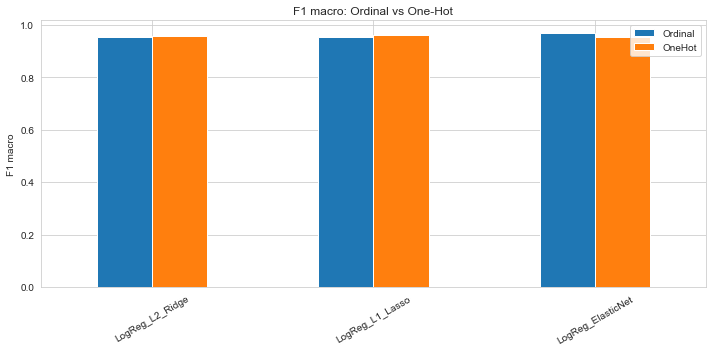

In [69]:
comparison = pd.DataFrame({
    'Ordinal': pd.Series({k: v['f1_macro'] for k, v in results_1.items()}),
    'OneHot': pd.Series({k: v['f1_macro'] for k, v in results_2.items()})
}).round(3)

print(comparison)
comparison.plot(kind='bar', figsize=(10, 5), title='F1 macro: Ordinal vs One-Hot')
plt.ylabel('F1 macro')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()